# Matplotlib

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Circle
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.text import Text
# ===============================
# Folders
# ===============================
csv_folder = "csv_files"
fig_folder = "figures"
os.makedirs(fig_folder, exist_ok=True)

# ===============================
# Temperatures
# ===============================
temperatures = list(range(300, 3301, 100))  # 300, 400, ..., 1200

# ===============================
# Load data
# ===============================
df_list = []

for T in temperatures:
    file_path = os.path.join(csv_folder, f"Gibbs_{T}K.csv")
    
    df_T = pd.read_csv(file_path)
    df_T["T"] = T
    df_T["DeltaG"] = df_T["G_FCC"] - df_T["G_LIQ"]
    
    df_list.append(df_T)

df_plot = pd.concat(df_list, ignore_index=True)

print("Loaded data shape:", df_plot.shape)
df_plot.head()

Loaded data shape: (1048451, 8)


,Co,Cr,Fe,Ni,G_LIQ,G_FCC,T,DeltaG
0,0.01,0.18,0.40,0.41,1585.148381,-8181.467835,300,-9766.616216
1,0.01,0.19,0.39,0.41,1641.972690,-8096.491911,300,-9738.464601
2,0.01,0.19,0.40,0.40,1695.009904,-7974.043612,300,-9669.053516
3,0.01,0.20,0.38,0.41,1705.339555,-8009.176388,300,-9714.515943
4,0.01,0.20,0.39,0.40,1755.114931,-7887.293191,300,-9642.408122


In [2]:
def draw_bezier(ax, x1, y1, x2, y2, color, lw=0.5, alpha=0.75):
    dx = x2 - x1
    c1 = (x1 + 0.35 * dx, y1)
    c2 = (x1 + 0.75 * dx, y2)
    verts = [(x1, y1), c1, c2, (x2, y2)]

    codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    path = Path(verts, codes)
    patch = PathPatch(path, facecolor="none", edgecolor=color, lw=lw, alpha=alpha)
    ax.add_patch(patch)

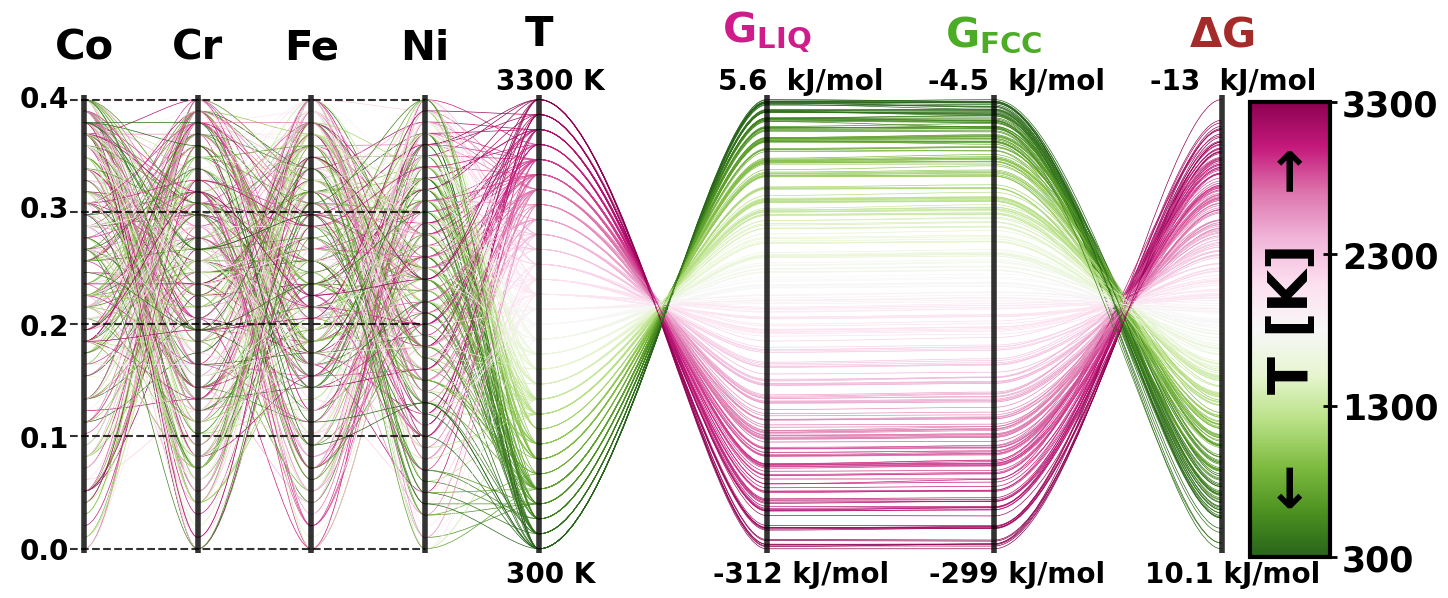

In [5]:
variables = ["Co", "Cr", "Fe", "Ni", "T",  "G_LIQ", "G_FCC", "DeltaG", ]
variables_names = ["Co", "Cr", "Fe", "Ni", "T",  r"G$_\mathbf{LIQ}$", r"G$_\mathbf{FCC}$", r"$\mathbf{\Delta}$G",]
# Optional downsampling
max_rows = 300 #3000

if len(df_plot) > max_rows:
    df_parallel = df_plot.sample(max_rows, random_state=42).copy()
else:
    df_parallel = df_plot.copy()

# Min-max normalization for plotting
df_norm = df_parallel[variables].copy()

for col in variables:
    col_min = df_norm[col].min()
    col_max = df_norm[col].max()
    
    if np.isclose(col_max, col_min):
        df_norm[col] = 0.5
    else:
        df_norm[col] = (df_norm[col] - col_min) / (col_max - col_min)

# ===============================
# Plot
# ===============================
fig, ax = plt.subplots(figsize=(16, 7), frameon=False)
ax.set_facecolor((0, 0, 0, 0))

# x = np.arange(len(variables))
x = np.array([0, 1, 2, 3, 4, 6, 8, 10])

norm_T = Normalize(vmin=df_parallel["T"].min(), vmax=df_parallel["T"].max())
cmap = plt.cm.PiYG_r #PiYG_r seismic

for idx in range(len(df_norm)):
    y = df_norm.iloc[idx].values
    color = cmap(norm_T(df_parallel.iloc[idx]["T"]))
    for j in range(len(variables) - 1):
        draw_bezier(ax, x[j], y[j], x[j + 1], y[j + 1], color=color, lw=0.5, alpha=0.99)


for i in range(4):
    ax.vlines(x=i, ymin=-0.01, ymax=1.01, color="black", linewidth=4, alpha=0.8, linestyle='-')
    ax.text(i, 1.07, variables_names[i], ha="center", va="bottom", fontsize=30, fontweight="bold")

ax.vlines(4, ymin=-0.01, ymax=1.01, color="black", linewidth=4, alpha=0.8, linestyle='-')
ax.vlines(6, ymin=-0.01, ymax=1.01, color="black", linewidth=4, alpha=0.8, linestyle='-')
ax.vlines(8, ymin=-0.01, ymax=1.01, color="black", linewidth=4, alpha=0.8, linestyle='-')
ax.vlines(10, ymin=-0.01, ymax=1.01, color="black", linewidth=4, alpha=0.8, linestyle='-')
ax.text(4, 1.10, variables_names[4], ha="center", va="bottom", fontsize=30, fontweight="bold")
ax.text(6, 1.10, variables_names[5], ha="center", va="bottom", fontsize=30, fontweight="bold", color='#d01c8b')
ax.text(8, 1.10, variables_names[6], ha="center", va="bottom", fontsize=30, fontweight="bold", color='#4dac26')
ax.text(10, 1.10, variables_names[7], ha="center", va="bottom", fontsize=30, fontweight="bold", color='brown')

    
ax.text(0-0.35, 0.025, f"{0.00}", ha="center", va="top", fontsize=20,  fontweight="bold")
ax.text(0-0.35, 0.275, f"{0.1}", ha="center", va="top", fontsize=20,  fontweight="bold")
ax.text(0-0.35, 0.525, f"{0.2}", ha="center", va="top", fontsize=20,  fontweight="bold")
ax.text(0-0.35, 0.725, f"{0.3}", ha="center", va="bottom", fontsize=20, fontweight="bold")
ax.text(0-0.35, 0.970, f"{0.4}", ha="center", va="bottom", fontsize=20, fontweight="bold")

ax.hlines(y=0,    xmin=-0.12, xmax=3, color="black", linewidth=1.5, alpha=0.8, linestyle ='--')
ax.hlines(y=0.25, xmin=-0.12, xmax=3, color="black", linewidth=1.5, alpha=0.8, linestyle ='--')
ax.hlines(y=0.5,  xmin=-0.12, xmax=3, color="black", linewidth=1.5, alpha=0.8, linestyle ='--')
ax.hlines(y=0.75, xmin=-0.12, xmax=3, color="black", linewidth=1.5, alpha=0.8, linestyle ='--')
ax.hlines(y=1,    xmin=-0.12, xmax=3, color="black", linewidth=1.5, alpha=0.8, linestyle ='--')


T_min, T_max = df_parallel['T'].min(), df_parallel['T'].max()
G_LIQ_min, G_LIQ_max = df_parallel['G_LIQ'].min(), df_parallel['G_LIQ'].max()
G_FCC_min, G_FCC_max = df_parallel['G_FCC'].min(), df_parallel['G_FCC'].max()
del_G_min, del_G_max = df_parallel['DeltaG'].min(), df_parallel['DeltaG'].max()


ax.text(4.1, -0.025, f"{T_min:.0f} K", ha="center", va="top", fontsize=20, rotation=0, fontweight="bold")
ax.text(4.1, 1.01, f"{T_max:.0f} K", ha="center", va="bottom", fontsize=20, rotation=0, fontweight="bold")

ax.text(6.3, -0.025, f"{G_LIQ_min/1000:.0f} kJ/mol", ha="center", va="top", fontsize=20, rotation=0, fontweight="bold")
ax.text(6.3, 1.01, f"{G_LIQ_max/1000:.1f}  kJ/mol", ha="center", va="bottom", fontsize=20, rotation=0, fontweight="bold")

ax.text(8.2, -0.025, f"{G_FCC_min/1000:.0f} kJ/mol", ha="center", va="top", fontsize=20, rotation=0, fontweight="bold")
ax.text(8.2, 1.01, f"{G_FCC_max/1000:.1f}  kJ/mol", ha="center", va="bottom", fontsize=20, rotation=0, fontweight="bold")

ax.text(10.1, 1.01,   f"{(G_LIQ_min-G_FCC_min)/1000:.0f}  kJ/mol", ha="center", va="bottom", fontsize=20, rotation=0, fontweight="bold")
ax.text(10.1, -0.025, f"{(G_LIQ_max-G_FCC_max)/1000:.1f} kJ/mol", ha="center", va="top", fontsize=20, rotation=0, fontweight="bold")

ax.set_xticks([])
ax.set_yticks([])
# Colorbar

ax1 = fig.add_axes([0.9, 0.13, 0.05, 0.65]) 
ax1.tick_params(axis='both', labelcolor='black', labelsize=1, bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

sm = ScalarMappable(norm=norm_T, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax1, orientation='vertical',)
cbar.ax.tick_params(labelsize=25, direction='inout', length=10, width=2)
cbar.set_ticks([300, 1300, 2300, 3300], labels=['300', '1300', '2300', '3300'], weight='bold') 
text = Text(x=0.91, y=0.2, text=r'$\mathbf{\leftarrow}$   T [K]  $\mathbf{\rightarrow}$', fontsize=40, color='k', rotation=90, weight='bold')
fig.add_artist(text)


ax.set_ylim(-0.05, 1.15)
ax.set_xlim(-0.65, 10.25)

ax.spines[:].set_linewidth(0)
ax1.spines[:].set_linewidth(3)

plt.savefig(os.path.join(fig_folder, "free_energy_viz.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(fig_folder, "free_energy_viz.jpg"), dpi=300, bbox_inches="tight")

plt.show()

In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ============================================================
# Output folder
# ============================================================
fig_folder = "figures"
os.makedirs(fig_folder, exist_ok=True)

# ============================================================
# Keep only the required columns
# ============================================================
cols = ["Co", "Cr", "Fe", "Ni", "T", "G_LIQ", "G_FCC"]

df_link = df_plot[cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

print("Data used for link visualization:", df_link.shape)
df_link.head()

Data used for link visualization: (1048451, 7)


,Co,Cr,Fe,Ni,T,G_LIQ,G_FCC
0,0.01,0.18,0.40,0.41,300,1585.148381,-8181.467835
1,0.01,0.19,0.39,0.41,300,1641.972690,-8096.491911
2,0.01,0.19,0.40,0.40,300,1695.009904,-7974.043612
3,0.01,0.20,0.38,0.41,300,1705.339555,-8009.176388
4,0.01,0.20,0.39,0.40,300,1755.114931,-7887.293191


/tmp/ipykernel_4133302/1906717804.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


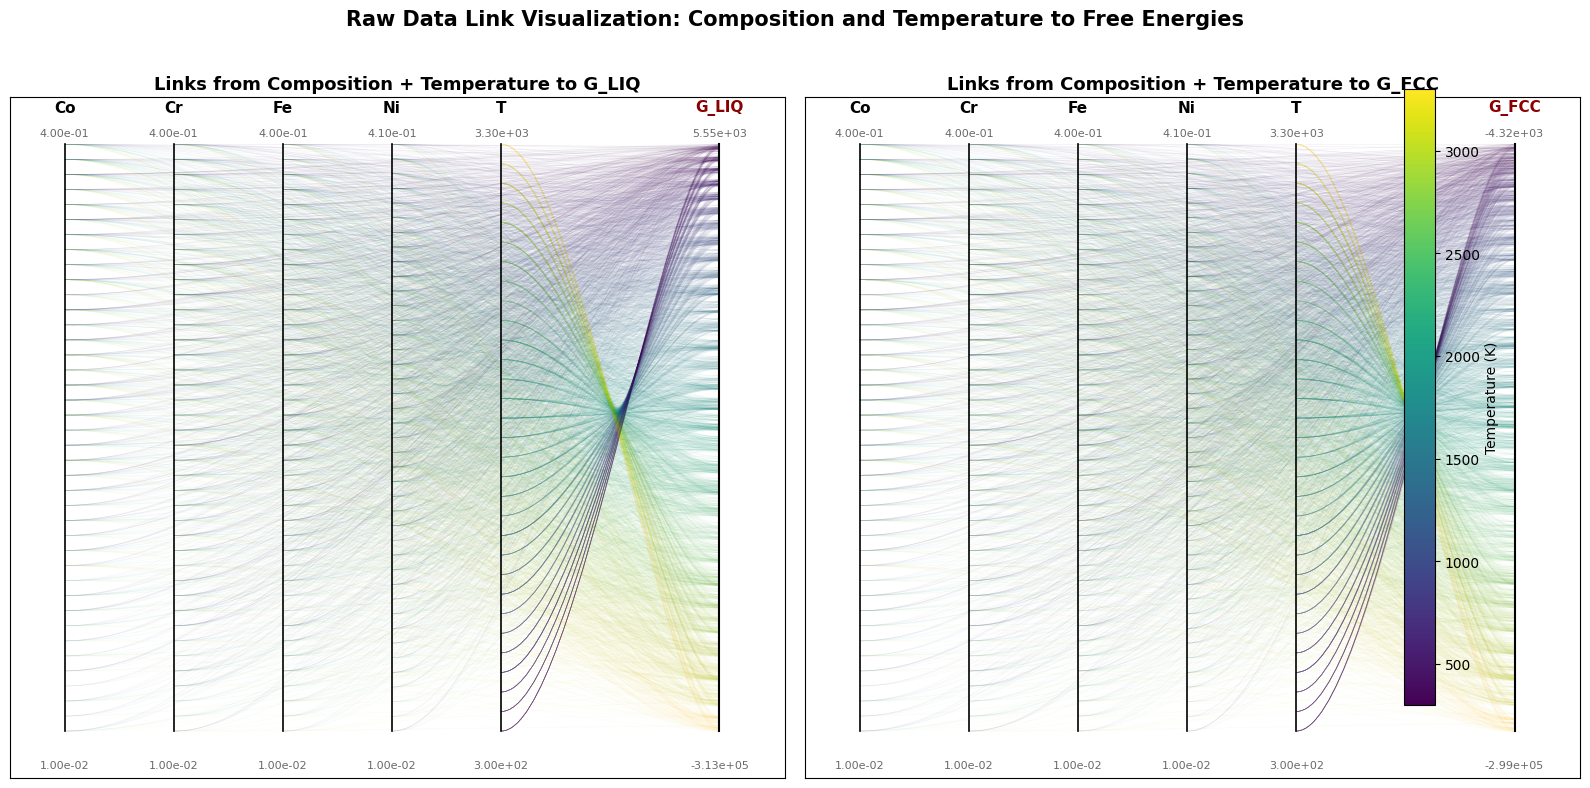

In [32]:
# ============================================================
# Optional downsampling
# Too many samples will make the plot too dense
# ============================================================
max_rows = 1200

if len(df_link) > max_rows:
    df_vis = df_link.sample(max_rows, random_state=42).copy()
else:
    df_vis = df_link.copy()

# ============================================================
# Normalize each variable independently to [0, 1]
# ============================================================
all_vars = ["Co", "Cr", "Fe", "Ni", "T", "G_LIQ", "G_FCC"]

df_norm = df_vis.copy()
minmax = {}

for col in all_vars:
    vmin = df_vis[col].min()
    vmax = df_vis[col].max()
    minmax[col] = (vmin, vmax)

    if np.isclose(vmin, vmax):
        df_norm[col] = 0.5
    else:
        df_norm[col] = (df_vis[col] - vmin) / (vmax - vmin)

# ============================================================
# Helper: draw a smooth cubic Bezier curve
# ============================================================
def draw_bezier(ax, x1, y1, x2, y2, color, lw=0.5, alpha=0.04):
    dx = x2 - x1

    c1 = (x1 + 0.35 * dx, y1)
    c2 = (x1 + 0.75 * dx, y2)

    verts = [
        (x1, y1),
        c1,
        c2,
        (x2, y2)
    ]
    codes = [
        Path.MOVETO,
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4
    ]

    path = Path(verts, codes)
    patch = PathPatch(
        path,
        facecolor="none",
        edgecolor=color,
        lw=lw,
        alpha=alpha
    )
    ax.add_patch(patch)

# ============================================================
# Plot settings
# ============================================================
input_vars = ["Co", "Cr", "Fe", "Ni", "T"]
output_vars = ["G_LIQ", "G_FCC"]

x_inputs = np.arange(len(input_vars))          # 0,1,2,3,4
x_output = 6.0                                 # output axis location

norm_T = Normalize(vmin=df_vis["T"].min(), vmax=df_vis["T"].max())
cmap = plt.cm.viridis

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

for ax, out_var in zip(axes, output_vars):

    # --------------------------------------------------------
    # Draw vertical axes for inputs and output
    # --------------------------------------------------------
    for i, var in enumerate(input_vars):
        ax.plot([x_inputs[i], x_inputs[i]], [0, 1], color="black", lw=1.2)
        ax.text(x_inputs[i], 1.05, var, ha="center", va="bottom",
                fontsize=11, fontweight="bold")

        vmin, vmax = minmax[var]
        ax.text(x_inputs[i], -0.05, f"{vmin:.2e}", ha="center", va="top",
                fontsize=8, color="dimgray")
        ax.text(x_inputs[i], 1.01, f"{vmax:.2e}", ha="center", va="bottom",
                fontsize=8, color="dimgray")

    # Output axis
    ax.plot([x_output, x_output], [0, 1], color="black", lw=1.5)
    ax.text(x_output, 1.05, out_var, ha="center", va="bottom",
            fontsize=11, fontweight="bold", color="darkred")

    vmin, vmax = minmax[out_var]
    ax.text(x_output, -0.05, f"{vmin:.2e}", ha="center", va="top",
            fontsize=8, color="dimgray")
    ax.text(x_output, 1.01, f"{vmax:.2e}", ha="center", va="bottom",
            fontsize=8, color="dimgray")

    # --------------------------------------------------------
    # Draw every link from each input to the output
    # --------------------------------------------------------
    for idx in range(len(df_norm)):
        row_n = df_norm.iloc[idx]
        row_o = df_vis.iloc[idx]

        color = cmap(norm_T(row_o["T"]))

        y_out = row_n[out_var]

        for i, var in enumerate(input_vars):
            y_in = row_n[var]
            draw_bezier(
                ax,
                x_inputs[i], y_in,
                x_output, y_out,
                color=color,
                lw=0.45,
                alpha=0.035
            )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------
    ax.set_xlim(-0.5, x_output + 0.6)
    ax.set_ylim(-0.08, 1.08)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Links from Composition + Temperature to {out_var}",
                 fontsize=13, fontweight="bold")

# ============================================================
# Global figure title
# ============================================================
fig.suptitle(
    "Raw Data Link Visualization: Composition and Temperature to Free Energies",
    fontsize=15,
    fontweight="bold",
    y=0.98
)

# ============================================================
# Colorbar for temperature
# ============================================================
sm = ScalarMappable(norm=norm_T, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
cbar.set_label("Temperature (K)")

plt.tight_layout(rect=[0, 0, 1, 0.96])

# ============================================================
# Save figure
# ============================================================
# plt.savefig(
#     os.path.join(fig_folder, "input_to_Gibbs_link_plot.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

plt.savefig(
    os.path.join(fig_folder, "input_to_Gibbs_link_plot.jpg"),
    dpi=300,
    bbox_inches="tight"
)

# plt.savefig(
#     os.path.join(fig_folder, "input_to_Gibbs_link_plot.pdf"),
#     bbox_inches="tight"
# )

plt.show()

In [35]:
import numpy as np
import pandas as pd

# Your wide dataframe is df_G, not df

import pandas as pd

df_G = pd.read_csv("CoCrFeNi_Gibbs_LIQ_FCC_300_3300K.csv")

df = df_G.copy()

temperatures = list(range(300, 3301, 100))

long_rows = []

for T in temperatures:
    col_liq = f'G_LIQ_T{T}'
    col_fcc = f'G_FCC_T{T}'
    
    if col_liq in df.columns and col_fcc in df.columns:
        temp_df = df[['c_Co', 'c_Cr', 'c_Fe', 'c_Ni', col_liq, col_fcc]].copy()
        temp_df.columns = ['Co', 'Cr', 'Fe', 'Ni', 'G_LIQ', 'G_FCC']
        temp_df['T'] = T
        long_rows.append(temp_df)

df_long = pd.concat(long_rows, ignore_index=True)

df_long['DeltaG'] = df_long['G_LIQ'] - df_long['G_FCC']

print("Long dataframe shape:", df_long.shape)
df_long.head()

Long dataframe shape: (1048451, 8)


,Co,Cr,Fe,Ni,G_LIQ,G_FCC,T,DeltaG
0,0.01,0.18,0.40,0.41,1585.148381,-8181.467835,300,9766.616216
1,0.01,0.19,0.39,0.41,1641.972690,-8096.491911,300,9738.464601
2,0.01,0.19,0.40,0.40,1695.009904,-7974.043612,300,9669.053516
3,0.01,0.20,0.38,0.41,1705.339555,-8009.176388,300,9714.515943
4,0.01,0.20,0.39,0.40,1755.114931,-7887.293191,300,9642.408122


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

def layered_link_plot(data, dims, color_by='T', sample_size=5000, 
                      cmap='viridis', alpha=0.12, linewidth=0.3,
                      title=None, save_path=None):
    """
    Plot layered parallel-link visualization for continuous multivariable data.
    
    Parameters
    ----------
    data : pandas.DataFrame
    dims : list of str
        Ordered columns to plot as layered axes.
    color_by : str
        Column used for coloring lines.
    sample_size : int or None
        Number of sampled rows for clarity. Use None for all rows.
    cmap : str
        Matplotlib colormap.
    alpha : float
        Line transparency.
    linewidth : float
        Line width.
    title : str
        Plot title.
    save_path : str or None
        If given, figure is saved to this path.
    """
    plot_df = data.copy()

    if sample_size is not None and len(plot_df) > sample_size:
        plot_df = plot_df.sample(sample_size, random_state=42)

    x = np.arange(len(dims))

    mins = plot_df[dims].min()
    maxs = plot_df[dims].max()
    denom = (maxs - mins).replace(0, 1.0)

    norm_df = (plot_df[dims] - mins) / denom

    segments = []
    color_vals = []

    for idx in range(len(plot_df)):
        y = norm_df.iloc[idx].values
        pts = np.column_stack([x, y])

        for j in range(len(dims) - 1):
            segments.append([pts[j], pts[j+1]])
            color_vals.append(plot_df.iloc[idx][color_by])

    color_vals = np.array(color_vals)

    fig, ax = plt.subplots(figsize=(16, 8), dpi=200)

    lc = LineCollection(
        segments,
        cmap=cmap,
        norm=Normalize(vmin=plot_df[color_by].min(), vmax=plot_df[color_by].max()),
        linewidths=linewidth,
        alpha=alpha
    )
    lc.set_array(color_vals)
    ax.add_collection(lc)

    # vertical axes
    for i, dim in enumerate(dims):
        ax.axvline(i, color='black', linewidth=1.0)

        ax.text(i, 1.06, dim, ha='center', va='bottom', fontsize=12, fontweight='bold')
        ax.text(i, -0.06, f'{mins[dim]:.4g}', ha='center', va='top', fontsize=9)
        ax.text(i, 1.01, f'{maxs[dim]:.4g}', ha='center', va='bottom', fontsize=9)

    ax.set_xlim(x[0] - 0.3, x[-1] + 0.3)
    ax.set_ylim(-0.08, 1.08)
    ax.set_xticks([])
    ax.set_yticks([])

    if title is not None:
        ax.set_title(title, fontsize=14, pad=20)

    cbar = fig.colorbar(lc, ax=ax, pad=0.02)
    cbar.set_label(color_by, fontsize=11)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

(33821, 66)